Module 10 - Session 2
AI Fairness and Bias Analysis

Exercise 1- Conceptual Questions

1. Types of Bias
The smart camera demonstrates dataset bias and representation bias
Dataset bias happens because the model was trained mainly on photos of light-skinned influencers
Representation bias occurs because dark-skinned users were underrepresented in the training data
As a result, the model performs well for one group but poorly for another group.

2. Fairness Metrics in Practice
Equal Opportunity is more suitable in this scenario
The city wants neighborhoods with similar fire risks to receive similar support regardless of demographics
Equal Opportunity focuses on treating individuals with similar true outcomes equally.

3. The Limits of Mitigation
Even after removing the gender column, the model may still learn gender-related patterns from proxy variables

Examples include
- first names
- career gaps
- universities attended
- hobbies
- previous job titles

These features may indirectly reveal gender information.

In [1]:
#xercise 2- Auditing the Adult Income Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("adult.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
high_income = (df['income'] == '>50K').mean() * 100
print(f"Overall percentage with income >50K: {high_income:.2f}%")

Overall percentage with income >50K: 24.08%


In [4]:
gender_analysis = df.groupby('sex')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
)

print(gender_analysis)

sex
Female    10.946059
Male      30.573658
Name: income, dtype: float64


In [5]:
race_analysis = df.groupby('race')['income'].apply(
    lambda x: (x == '>50K').mean() * 100
)

print(race_analysis)

race
Amer-Indian-Eskimo    11.575563
Asian-Pac-Islander    26.564004
Black                 12.387964
Other                  9.225092
White                 25.585994
Name: income, dtype: float64


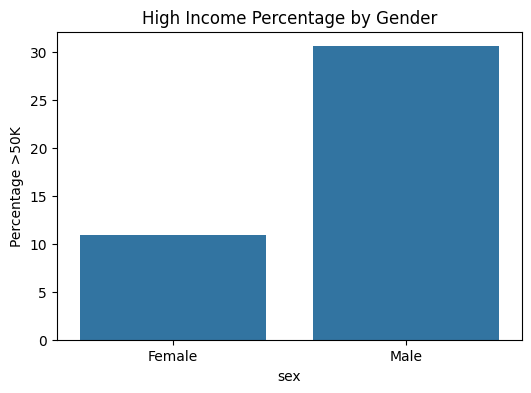

In [6]:
plt.figure(figsize=(6,4))

sns.barplot(
    x=gender_analysis.index,
    y=gender_analysis.values
)

plt.title("High Income Percentage by Gender")
plt.ylabel("Percentage >50K")

plt.show()

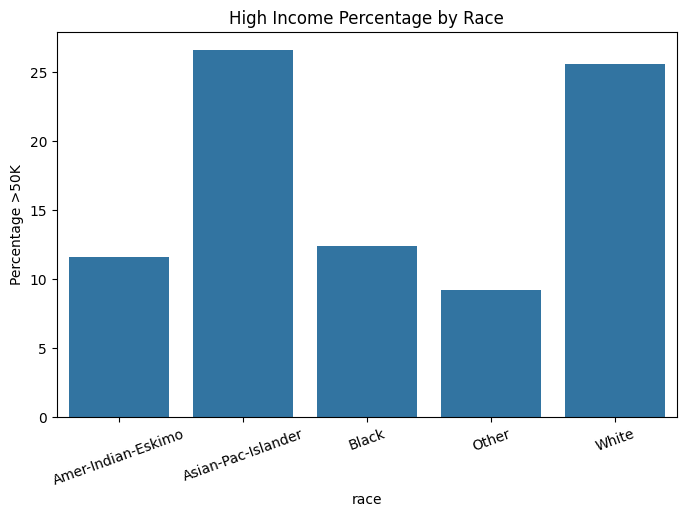

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=race_analysis.index,
    y=race_analysis.values
)

plt.title("High Income Percentage by Race")
plt.ylabel("Percentage >50K")

plt.xticks(rotation=20)

plt.show()

The dataset shows noticeable disparities between genders and races regarding high income levels
Males generally have a much higher percentage of income above 50K compared to females
Some racial groups also have significantly different outcomes
If a machine learning model is trained on this dataset without fairness mitigation, it may learn and reproduce these historical biases.

Exercise 3- The Paradox of Fairness

Achieving perfect Demographic Parity may create new problems even if it appears fair mathematically
If Group A historically has a lower default rate than Group B, forcing equal approval rates could increase financial losses for the bank. The bank may approve more risky loans from Group B while rejecting safer applicants from Group A
This may also affect Equal Opportunity. Some highly qualified applicants from Group A could now be rejected only to maintain equal approval statistics. In this situation, fairness toward groups may reduce fairness toward individuals
This example shows that fairness in AI is not simple. Different fairness metrics may conflict with each other, and improving one metric can worsen another
The role of the data scientist is to measure bias, explain trade-offs, and provide transparent analysis. However, the final decisions should involve business leaders, policymakers, and legal experts because these choices affect society, ethics, and economics.